# 05 · Predictor a 30 días: ¿cambia algo con más horizonte?

El notebook 04 predice el **retorno del día siguiente** y su conclusión es
que ningún modelo bate a predecir una constante. Este notebook comprueba si
eso es una propiedad del problema o del **horizonte elegido**.

**La razón para probarlo.** El retorno diario es casi puro ruido: su
desviación típica es 92 veces su media. Al predecir la **media de los
próximos 30 días**, el ruido se divide por ~√30 mientras la señal (la
deriva) se mantiene:

| horizonte | media | desv. típica | ruido/señal |
|---|---|---|---|
| 1 día | 0.000261 | 0.023966 | **91.9×** |
| 5 días | 0.000260 | 0.010000 | 38.4× |
| 30 días | 0.000260 | 0.003800 | **14.6×** |

Seis veces mejor relación señal/ruido. Es una tarea distinta, y merece
comprobarse antes de concluir que los sintéticos no sirven para nada.

Nota sobre el enunciado: no pide ningún horizonte concreto ("los datos son
a elección de los estudiantes... un problema financiero interesante"). El
día siguiente fue una decisión del grupo, no un requisito.

## Qué se compara

- **`constante`**: predecir la media por banco del entrenamiento. El modelo
  nulo — si nada lo bate, no hay señal.
- **`solo_reales`**: entrenar solo con la ventana real (2020-11 en adelante).
- **1, 2, 5, 10 y ~24 años** de backfill sintético añadido, **por cada uno
  de los 4 generadores** (Ruido, Gaussiana, RBIG, GAN).

1 + 5×4 = **21 modelos**, todos evaluados en el MISMO test real.

## Diferencias metodológicas respecto al notebook 04

1. **Red densa sencilla** en vez de la LSTM: el objetivo aquí es la
   comparación entre datasets, no exprimir la arquitectura.
2. **Embargo de 90 días** (`WINDOW_X` 60 + `WINDOW_Y` 30) en vez de 60. Con
   un target a 30 días vista, una fila fechada 29 días antes de la
   validación tiene su *target* dentro del tramo de validación: eso sí
   sería fuga real, no solo solape de entradas.
3. **Bootstrap por BLOQUES** para los intervalos de confianza. Las ventanas
   de 30 días se solapan (el target de hoy y el de mañana comparten 29
   días), así que remuestrear días sueltos daría intervalos falsamente
   estrechos.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import backfill as bf, config, features as feat, modelos
from src import plotting as pl, train_utils as tu

WINDOW_Y = 30                       # media de los proximos 30 dias
EMBARGO_DAYS = config.WINDOW_X_DAYS + WINDOW_Y      # 90
TRAIN_END = str((pd.Timestamp(config.VAL_START_DATE) - pd.Timedelta(days=EMBARGO_DAYS)).date())
PROFUNDIDADES = [1, 2, 5, 10, 24]   # anios de sintetico; 24 ~= todo lo disponible
GENERADORES = ["noise", "gaussian", "rbig", "gan"]
EPOCHS, BATCH, PATIENCE = 400, 256, 20
MIN_EPOCHS = 100          # ninguna parada antes de la epoca 100

# Regularizacion FIJADA a mano, no la que optimiza el MAE de validacion.
# La busqueda de la seccion 4 elige dropout=0 y L2=0 porque son los que
# minimizan el val_MAE, pero dejan curvas con sobreajuste visible (val_loss
# sube +5.9% de mediana tras el minimo). El enunciado pide explicitamente
# "curvas de loss donde se vea que el modelo ha convergido", asi que se fija
# la regularizacion y se acepta el ~0.7% de MAE que cuesta.
DROPOUT, L2 = 0.3, 1e-4

print(f"horizonte: media de {WINDOW_Y} dias | embargo: {EMBARGO_DAYS} dias "
      f"| entrenamiento hasta {TRAIN_END}")

horizonte: media de 30 dias | embargo: 90 dias | entrenamiento hasta 2025-03-03


## 1. Reconstruir los paneles de volatilidad (mismo backfill del notebook 03)

Los `dataset_*.npz` del notebook 03 tienen el target a 1 día ya calculado,
así que hay que rehacer las ventanas desde los paneles. El backfill es
determinista (`config.RANDOM_SEED`) y cuesta segundos.

In [2]:
returns = pd.read_parquet(config.INTERIM_DIR / "returns_predictor.parquet")
returns = returns[returns.index >= pd.Timestamp(config.TOTAL_HISTORY_START_DATE)]
intraday = pd.read_parquet(config.INTERIM_DIR / "intraday_features_real.parquet")
real_feats = {
    tk: g.set_index("date")[feat.INTRADAY_FEATURE_COLS]
    for tk, g in intraday[intraday.ticker.isin(config.PREDICTOR_TICKERS)].groupby("ticker")
}

datasets = {}
for name in GENERADORES:
    pool = np.load(config.INTERIM_DIR / f"synthetic_pool_{name}.npy")
    full = bf.build_full_history_features(returns, real_feats, pool,
                                          real_start=config.REAL_INTRADAY_START_DATE,
                                          k_neighbors=80)
    rv = bf.rv_panel_from_full_history(full)
    combinado = pd.concat(
        [returns[config.PREDICTOR_TICKERS],
         rv[config.PREDICTOR_TICKERS].add_suffix("_rv")], axis=1).dropna()
    X, Y_wide, idx = feat.build_xy_windows(combinado, config.WINDOW_X_DAYS, WINDOW_Y)
    Y = Y_wide[:, : config.N_PREDICTOR_TICKERS]
    is_synth = np.asarray(idx < pd.Timestamp(config.REAL_INTRADAY_START_DATE))
    datasets[name] = (X.astype("float32"), Y.astype("float32"), idx, is_synth)
    print(f"{name}: X {X.shape}  Y {Y.shape}  {idx.min().date()} -> {idx.max().date()}")

X_ref, Y_ref, idx_ref, is_synth_ref = datasets["noise"]

noise: X (7293, 60, 50)  Y (7293, 25)  1996-12-09 -> 2026-04-15


gaussian: X (7293, 60, 50)  Y (7293, 25)  1996-12-09 -> 2026-04-15


rbig: X (7293, 60, 50)  Y (7293, 25)  1996-12-09 -> 2026-04-15


gan: X (7293, 60, 50)  Y (7293, 25)  1996-12-09 -> 2026-04-15


## 2. Validación y test (reales, idénticos para los 21 modelos)

In [3]:
val_mask = (idx_ref >= pd.Timestamp(config.VAL_START_DATE)) & (
    idx_ref < pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE))
test_mask = idx_ref >= pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE)
X_val, Y_val = X_ref[val_mask], Y_ref[val_mask]
X_test, Y_test = X_ref[test_mask], Y_ref[test_mask]
idx_test = idx_ref[test_mask]
print(f"val: {X_val.shape}   test: {X_test.shape}")

X_real, Y_real, _, _ = tu.slice_by_depth(
    X_ref, Y_ref, idx_ref, 0, TRAIN_END, config.REAL_INTRADAY_START_DATE, is_synth_ref)
print(f"train solo reales: {X_real.shape}")

val: (126, 60, 50)   test: (93, 60, 50)
train solo reales: (1082, 60, 50)


## 3. El modelo nulo: predecir la media

Se calcula primero porque es la referencia contra la que se lee todo lo
demás.

In [4]:
modelo_cte = modelos.build_predictor_constant().fit(X_real, Y_real)
metricas_cte = tu.evaluate_predictor(modelo_cte, X_test, Y_test)
MAE_CONSTANTE = metricas_cte["mae"]
print(f"CONSTANTE -> test MAE {MAE_CONSTANTE:.6f} | "
      f"precisión direccional {metricas_cte['directional_accuracy']:.1%}")

CONSTANTE -> test MAE 0.002219 | precisión direccional 59.3%


## 4. Búsqueda de hiperparámetros: learning rate, dropout y L2

Como pide el enunciado ("usando los datos reales se buscará una
arquitectura válida"), la búsqueda usa **solo datos reales** y se mide en
**validación**. La configuración ganadora se congela y se reutiliza en los
21 entrenamientos, para que lo único que cambie entre ellos sea el dataset.

In [5]:
REJILLA_HP = [
    (lr, dr, l2)
    for lr in (1e-4, 3e-4, 1e-3)
    for dr in (0.0, 0.3, 0.5)          # incluye el 0.3 que se acaba fijando
    for l2 in (0.0, 1e-4, 1e-3)
]
print(f"{len(REJILLA_HP)} configuraciones de hiperparámetros")

filas_hp = []
for lr, dr, l2 in REJILLA_HP:
    tu.set_seed()
    m = modelos.build_predictor_dense(
        config.WINDOW_X_DAYS, X_ref.shape[-1], config.N_PREDICTOR_TICKERS,
        hidden_units=(64, 32), loss="mae", dropout=dr, l2=l2, learning_rate=lr)
    h = m.fit(X_real, Y_real, epochs=EPOCHS, batch_size=BATCH,
              validation_data=(X_val, Y_val), verbose=0,
              callbacks=tu._make_early_stopping(PATIENCE, MIN_EPOCHS))
    filas_hp.append({"learning_rate": lr, "dropout": dr, "l2": l2,
                     "val_mae": min(h.history["val_loss"]),
                     "epocas": len(h.history["loss"])})
    from tensorflow import keras
    keras.backend.clear_session()

hp = pd.DataFrame(filas_hp).sort_values("val_mae").reset_index(drop=True)
hp.to_csv(config.TABLES_DIR / "05_hiperparametros_30dias.csv", index=False)

# El learning rate SI sale de la busqueda, pero condicionado a la
# regularizacion ya fijada arriba: se compara like-for-like en vez de
# heredar el lr de una configuracion sin regularizar.
_cand = hp[(hp.dropout == DROPOUT) & (hp.l2 == L2)].sort_values("val_mae")
LR = float(_cand.iloc[0]["learning_rate"])
print(f"\nMejor absoluta de la busqueda: lr={hp.loc[0,'learning_rate']:g} "
      f"dropout={hp.loc[0,'dropout']:g} l2={hp.loc[0,'l2']:g} "
      f"-> val MAE {hp.loc[0,'val_mae']:.6f}")
print(f"ELEGIDA (regularizacion fijada): lr={LR:g} dropout={DROPOUT} l2={L2} "
      f"-> val MAE {_cand.iloc[0]['val_mae']:.6f}")
print(f"  coste de fijar la regularizacion: "
      f"{(_cand.iloc[0]['val_mae'] - hp.loc[0,'val_mae'])/hp.loc[0,'val_mae']*100:+.2f}% de val MAE")
hp.head(10).round(6)

27 configuraciones de hiperparámetros


/private/tmp/claude-501/-Users-emiliosanchez-TallerB5-T1/5719b493-09bf-4874-bc08-16a36a93b8f9/scratchpad/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Mejor absoluta de la busqueda: lr=0.0003 dropout=0.3 l2=0 -> val MAE 0.002014
ELEGIDA (regularizacion fijada): lr=0.001 dropout=0.3 l2=0.0001 -> val MAE 0.002049
  coste de fijar la regularizacion: +1.72% de val MAE


,learning_rate,dropout,l2,val_mae,epocas
0,0.0003,0.3,0.0000,0.002014,187
1,0.0010,0.0,0.0000,0.002022,138
2,0.0010,0.3,0.0000,0.002042,152
3,0.0010,0.0,0.0010,0.002044,181
4,0.0010,0.5,0.0000,0.002044,139
5,0.0003,0.5,0.0000,0.002046,125
6,0.0010,0.5,0.0010,0.002046,184
7,0.0010,0.5,0.0001,0.002046,203
8,0.0010,0.3,0.0010,0.002047,194
9,0.0010,0.3,0.0001,0.002049,198


Efecto marginal de cada hiperparámetro (media de `val_mae` sobre el resto):

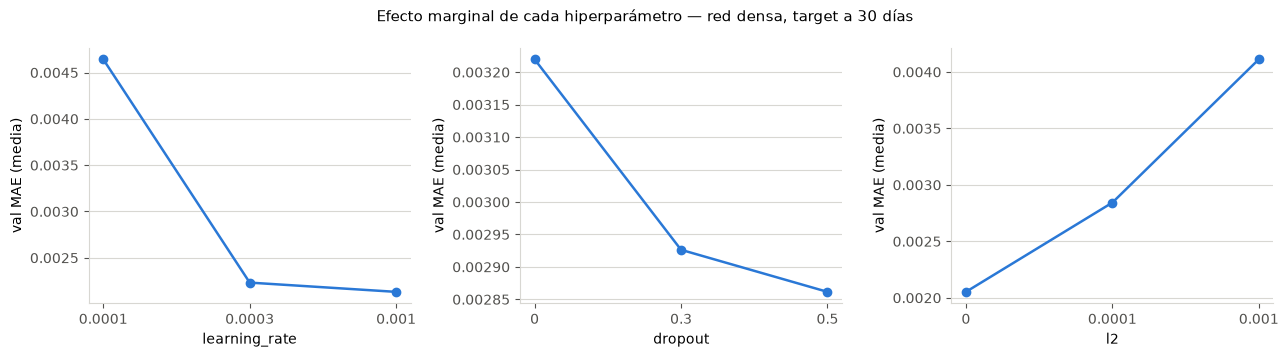

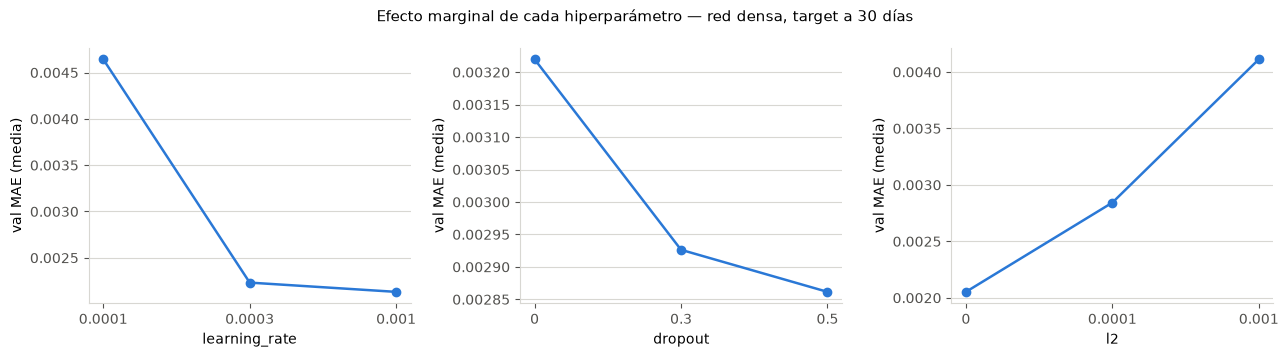

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, ["learning_rate", "dropout", "l2"]):
    g = hp.groupby(col)["val_mae"].mean()
    ax.plot(range(len(g)), g.values, marker="o", linewidth=1.8, color=pl.PALETTE["real"])
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels([f"{v:g}" for v in g.index])
    ax.set_xlabel(col)
    ax.set_ylabel("val MAE (media)")
    pl.style_axes(ax)
fig.suptitle("Efecto marginal de cada hiperparámetro — red densa, target a 30 días", fontsize=11)
fig.tight_layout()
pl.savefig(fig, "05_hiperparametros_30dias")
fig

## 5. Los 21 modelos

`solo_reales` una vez, y luego cada profundidad × cada generador.

In [7]:
def construir():
    return modelos.build_predictor_dense(
        config.WINDOW_X_DAYS, X_ref.shape[-1], config.N_PREDICTOR_TICKERS,
        hidden_units=(64, 32), loss="mae",
        dropout=DROPOUT, l2=L2, learning_rate=LR)


def entrenar(X_tr, Y_tr, etiqueta):
    tu.set_seed()
    m = construir()
    h = m.fit(X_tr, Y_tr, epochs=EPOCHS, batch_size=BATCH,
              validation_data=(X_val, Y_val), verbose=0,
              callbacks=tu._make_early_stopping(PATIENCE, MIN_EPOCHS))
    met = tu.evaluate_predictor(m, X_test, Y_test)
    pred = np.asarray(m.predict(X_test, verbose=0)).reshape(Y_test.shape)
    from tensorflow import keras
    keras.backend.clear_session()
    print(f"  {etiqueta:26s} n={len(X_tr):5d}  ep={len(h.history['loss']):3d}  "
          f"MAE={met['mae']:.6f}  dir={met['directional_accuracy']:.1%}")
    return met, h.history, pred


resultados, historiales, predicciones = [], {}, {}

met, hist, pred = entrenar(X_real, Y_real, "solo_reales")
resultados.append({"generador": "solo_reales", "anios_sinteticos": 0,
                   "n_train": len(X_real), "pct_synth": 0.0, **met})
historiales["solo_reales|0"] = hist
predicciones["solo_reales|0"] = pred

for anios in PROFUNDIDADES:
    for gen_name in GENERADORES:
        Xg, Yg, idxg, isyng = datasets[gen_name]
        X_tr, Y_tr, _, pct = tu.slice_by_depth(
            Xg, Yg, idxg, anios, TRAIN_END, config.REAL_INTRADAY_START_DATE, isyng)
        met, hist, pred = entrenar(X_tr, Y_tr, f"{gen_name} +{anios}a")
        resultados.append({"generador": gen_name, "anios_sinteticos": anios,
                           "n_train": len(X_tr), "pct_synth": pct, **met})
        historiales[f"{gen_name}|{anios}"] = hist
        predicciones[f"{gen_name}|{anios}"] = pred

res = pd.DataFrame(resultados)
res["vs_constante_pct"] = (res["mae"] - MAE_CONSTANTE) / MAE_CONSTANTE * 100
res.to_csv(config.TABLES_DIR / "05_resultados_30dias.csv", index=False)
res.round(6)

/private/tmp/claude-501/-Users-emiliosanchez-TallerB5-T1/5719b493-09bf-4874-bc08-16a36a93b8f9/scratchpad/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


  solo_reales                n= 1082  ep=198  MAE=0.002253  dir=56.2%


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

...

  rbig +24a                  n= 7011  ep=128  MAE=0.002192  dir=59.3%


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


  gan +24a                   n= 7011  ep=128  MAE=0.002192  dir=59.3%


,generador,anios_sinteticos,n_train,pct_synth,mse,mae,directional_accuracy,vs_constante_pct
0,solo_reales,0,1082,0.000000,0.000008,0.002253,0.561720,1.550145
1,noise,1,1333,0.188297,0.000007,0.002222,0.569032,0.121559
2,gaussian,1,1333,0.188297,0.000007,0.002223,0.554839,0.187034
3,rbig,1,1333,0.188297,0.000007,0.002221,0.554839,0.107278
4,gan,1,1333,0.188297,0.000007,0.002222,0.569032,0.131758
5,noise,2,1583,0.316488,0.000007,0.002220,0.562151,0.049075
6,gaussian,2,1583,0.316488,0.000007,0.002220,0.562151,0.065433
7,rbig,2,1583,0.316488,0.000007,0.002220,0.562151,0.060837
8,gan,2,1583,0.316488,0.000007,0.002222,0.562151,0.117488
9,noise,5,2340,0.537607,0.000007,0.002203,0.593118,-0.736364


## 6. ¿Alguno bate a la media?

Intervalos por **bootstrap de bloques** de 30 días: las ventanas se
solapan, así que remuestrear días sueltos daría intervalos demasiado
estrechos y haría parecer significativa cualquier diferencia.

In [8]:
def bootstrap_bloques(err, n_boot=2000, bloque=WINDOW_Y, seed=config.RANDOM_SEED):
    """err: (n_dias, n_bancos) de errores absolutos. Remuestrea BLOQUES
    contiguos de `bloque` dias para respetar el solape de las ventanas."""
    rng = np.random.default_rng(seed)
    n = len(err)
    n_bloques = max(n // bloque, 1)
    inicios = np.arange(0, max(n - bloque + 1, 1))
    out = np.empty(n_boot)
    for b in range(n_boot):
        sel = rng.choice(inicios, size=n_bloques, replace=True)
        out[b] = np.concatenate([err[s:s + bloque] for s in sel]).mean()
    return out


err_cte = np.abs(Y_test - modelo_cte.predict(X_test))
boot_cte = bootstrap_bloques(err_cte)
SE_BLOQUES = boot_cte.std()
print(f"MAE constante {MAE_CONSTANTE:.6f}  "
      f"e.e. (bootstrap de bloques) {SE_BLOQUES:.6f}  "
      f"IC95% [{np.percentile(boot_cte, 2.5):.6f}, {np.percentile(boot_cte, 97.5):.6f}]")

mejores = res.nsmallest(5, "mae")[["generador", "anios_sinteticos", "n_train", "mae", "vs_constante_pct"]]
print("\nlos 5 mejores frente a la constante:")
print(mejores.round(6).to_string(index=False))
n_baten = int((res["mae"] < MAE_CONSTANTE - SE_BLOQUES).sum())
print(f"\nmodelos que baten a la constante por MAS de 1 e.e.: {n_baten} de {len(res)}")

MAE constante 0.002219  e.e. (bootstrap de bloques) 0.000222  IC95% [0.001980, 0.002835]

los 5 mejores frente a la constante:
generador  anios_sinteticos  n_train      mae  vs_constante_pct
 gaussian                24     7011 0.002190         -1.282883
      gan                24     7011 0.002192         -1.217009
     rbig                24     7011 0.002192         -1.212832
    noise                24     7011 0.002193         -1.165426
    noise                 5     2340 0.002203         -0.736364

modelos que baten a la constante por MAS de 1 e.e.: 0 de 21


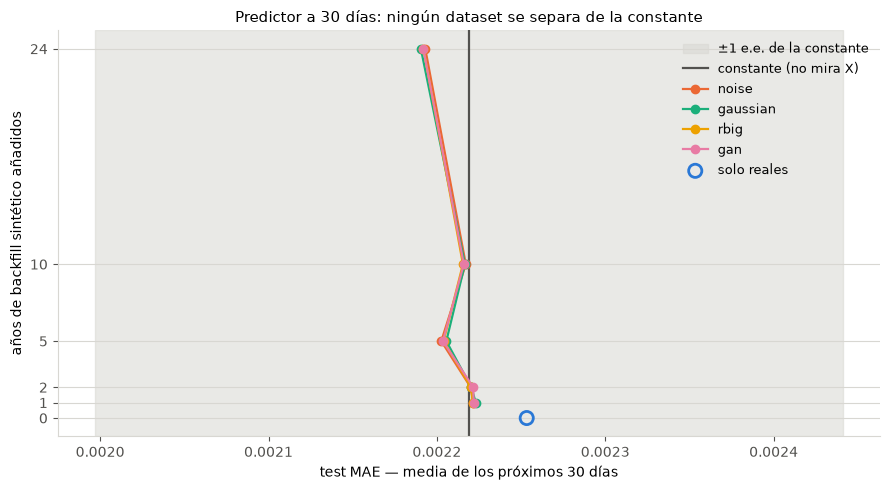

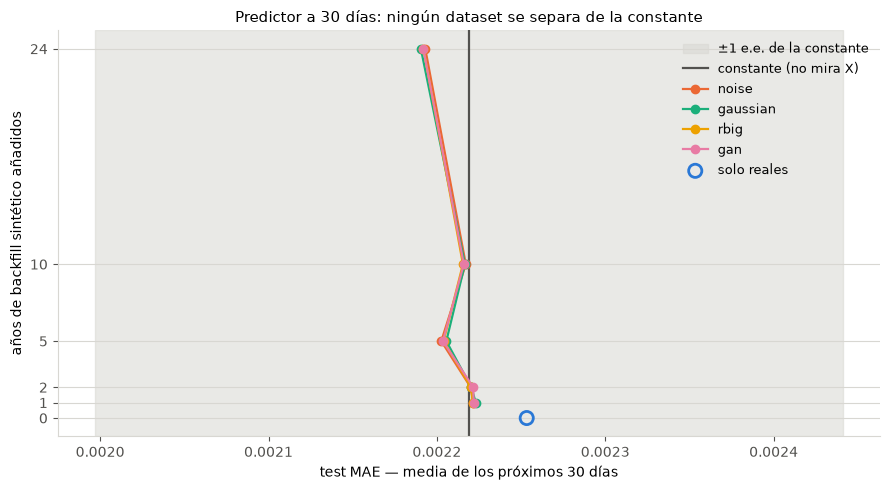

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(MAE_CONSTANTE - SE_BLOQUES, MAE_CONSTANTE + SE_BLOQUES,
           color=pl.MUTED_GRID, alpha=0.55, label="±1 e.e. de la constante")
ax.axvline(MAE_CONSTANTE, color="#52514e", linewidth=1.6, label="constante (no mira X)")
for gen_name in GENERADORES:
    sub = res[res.generador == gen_name].sort_values("anios_sinteticos")
    ax.plot(sub["mae"], sub["anios_sinteticos"], marker="o", linewidth=1.6,
            color=pl.color_for(gen_name), label=gen_name)
solo = res[res.generador == "solo_reales"].iloc[0]
ax.scatter([solo["mae"]], [0], s=90, facecolors="none",
           edgecolors=pl.PALETTE["solo_reales"], linewidths=2, label="solo reales", zorder=5)
ax.set_yticks([0] + PROFUNDIDADES)
ax.set_ylabel("años de backfill sintético añadidos")
ax.set_xlabel("test MAE — media de los próximos 30 días")
ax.set_title("Predictor a 30 días: ningún dataset se separa de la constante", fontsize=11)
ax.legend(frameon=False, fontsize=9)
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "05_resultado_30dias")
fig

## 7. Curvas de convergencia

El enunciado exige, para **cada** entrenamiento, la curva de loss donde se
vea que el modelo ha convergido.

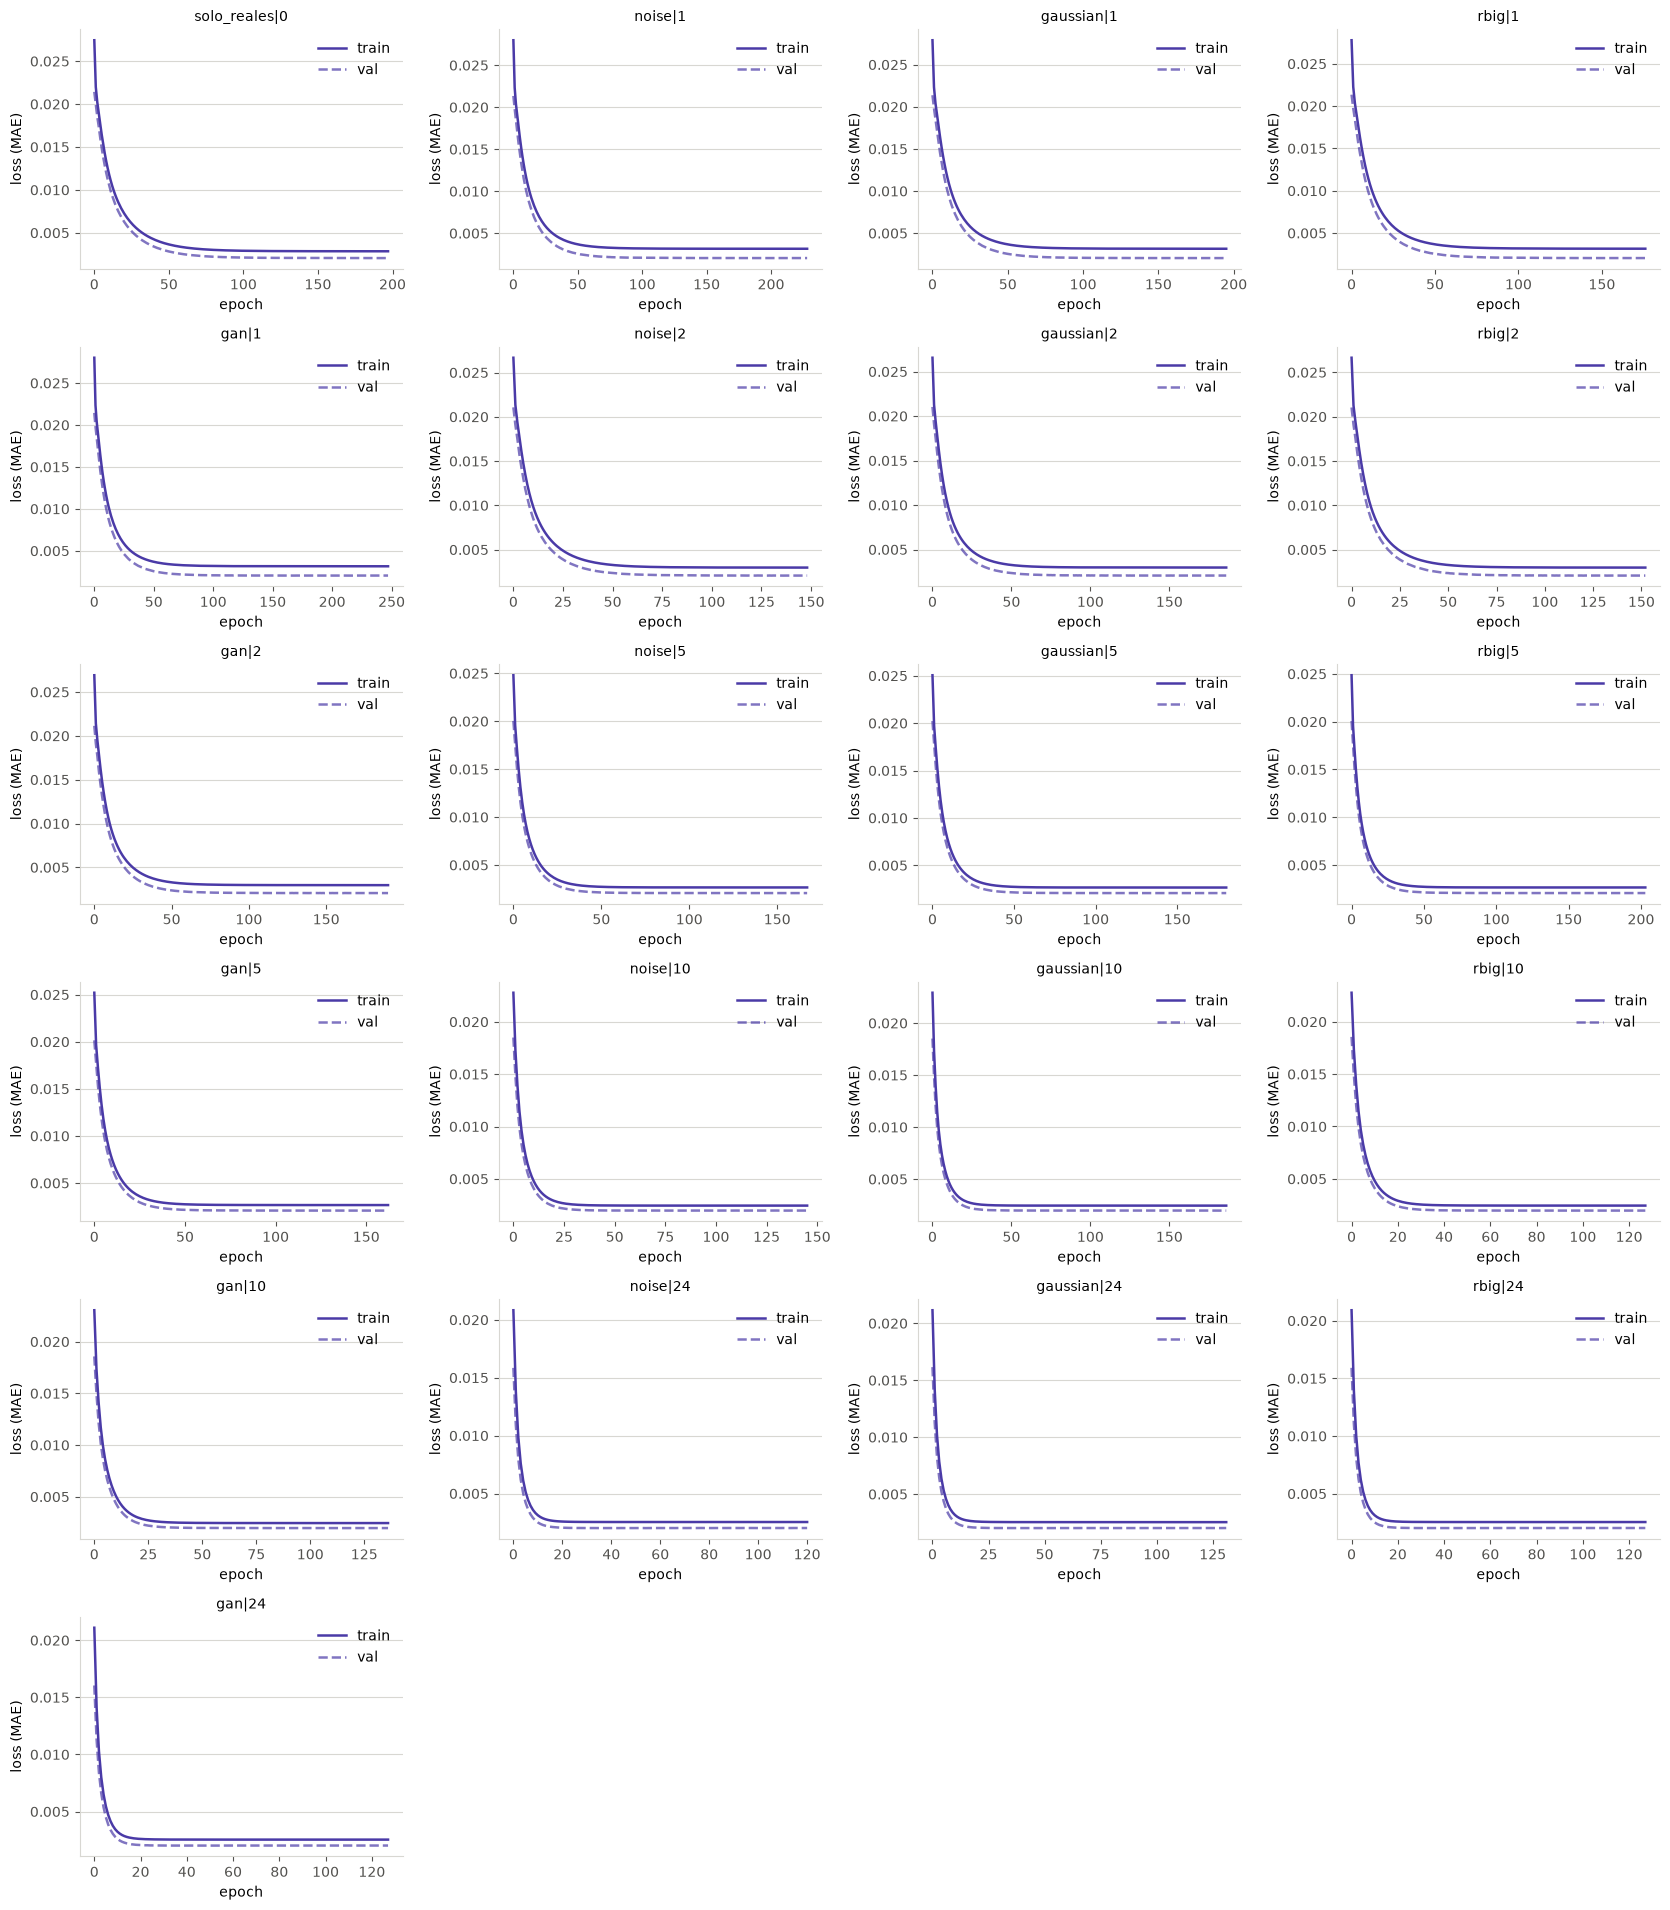

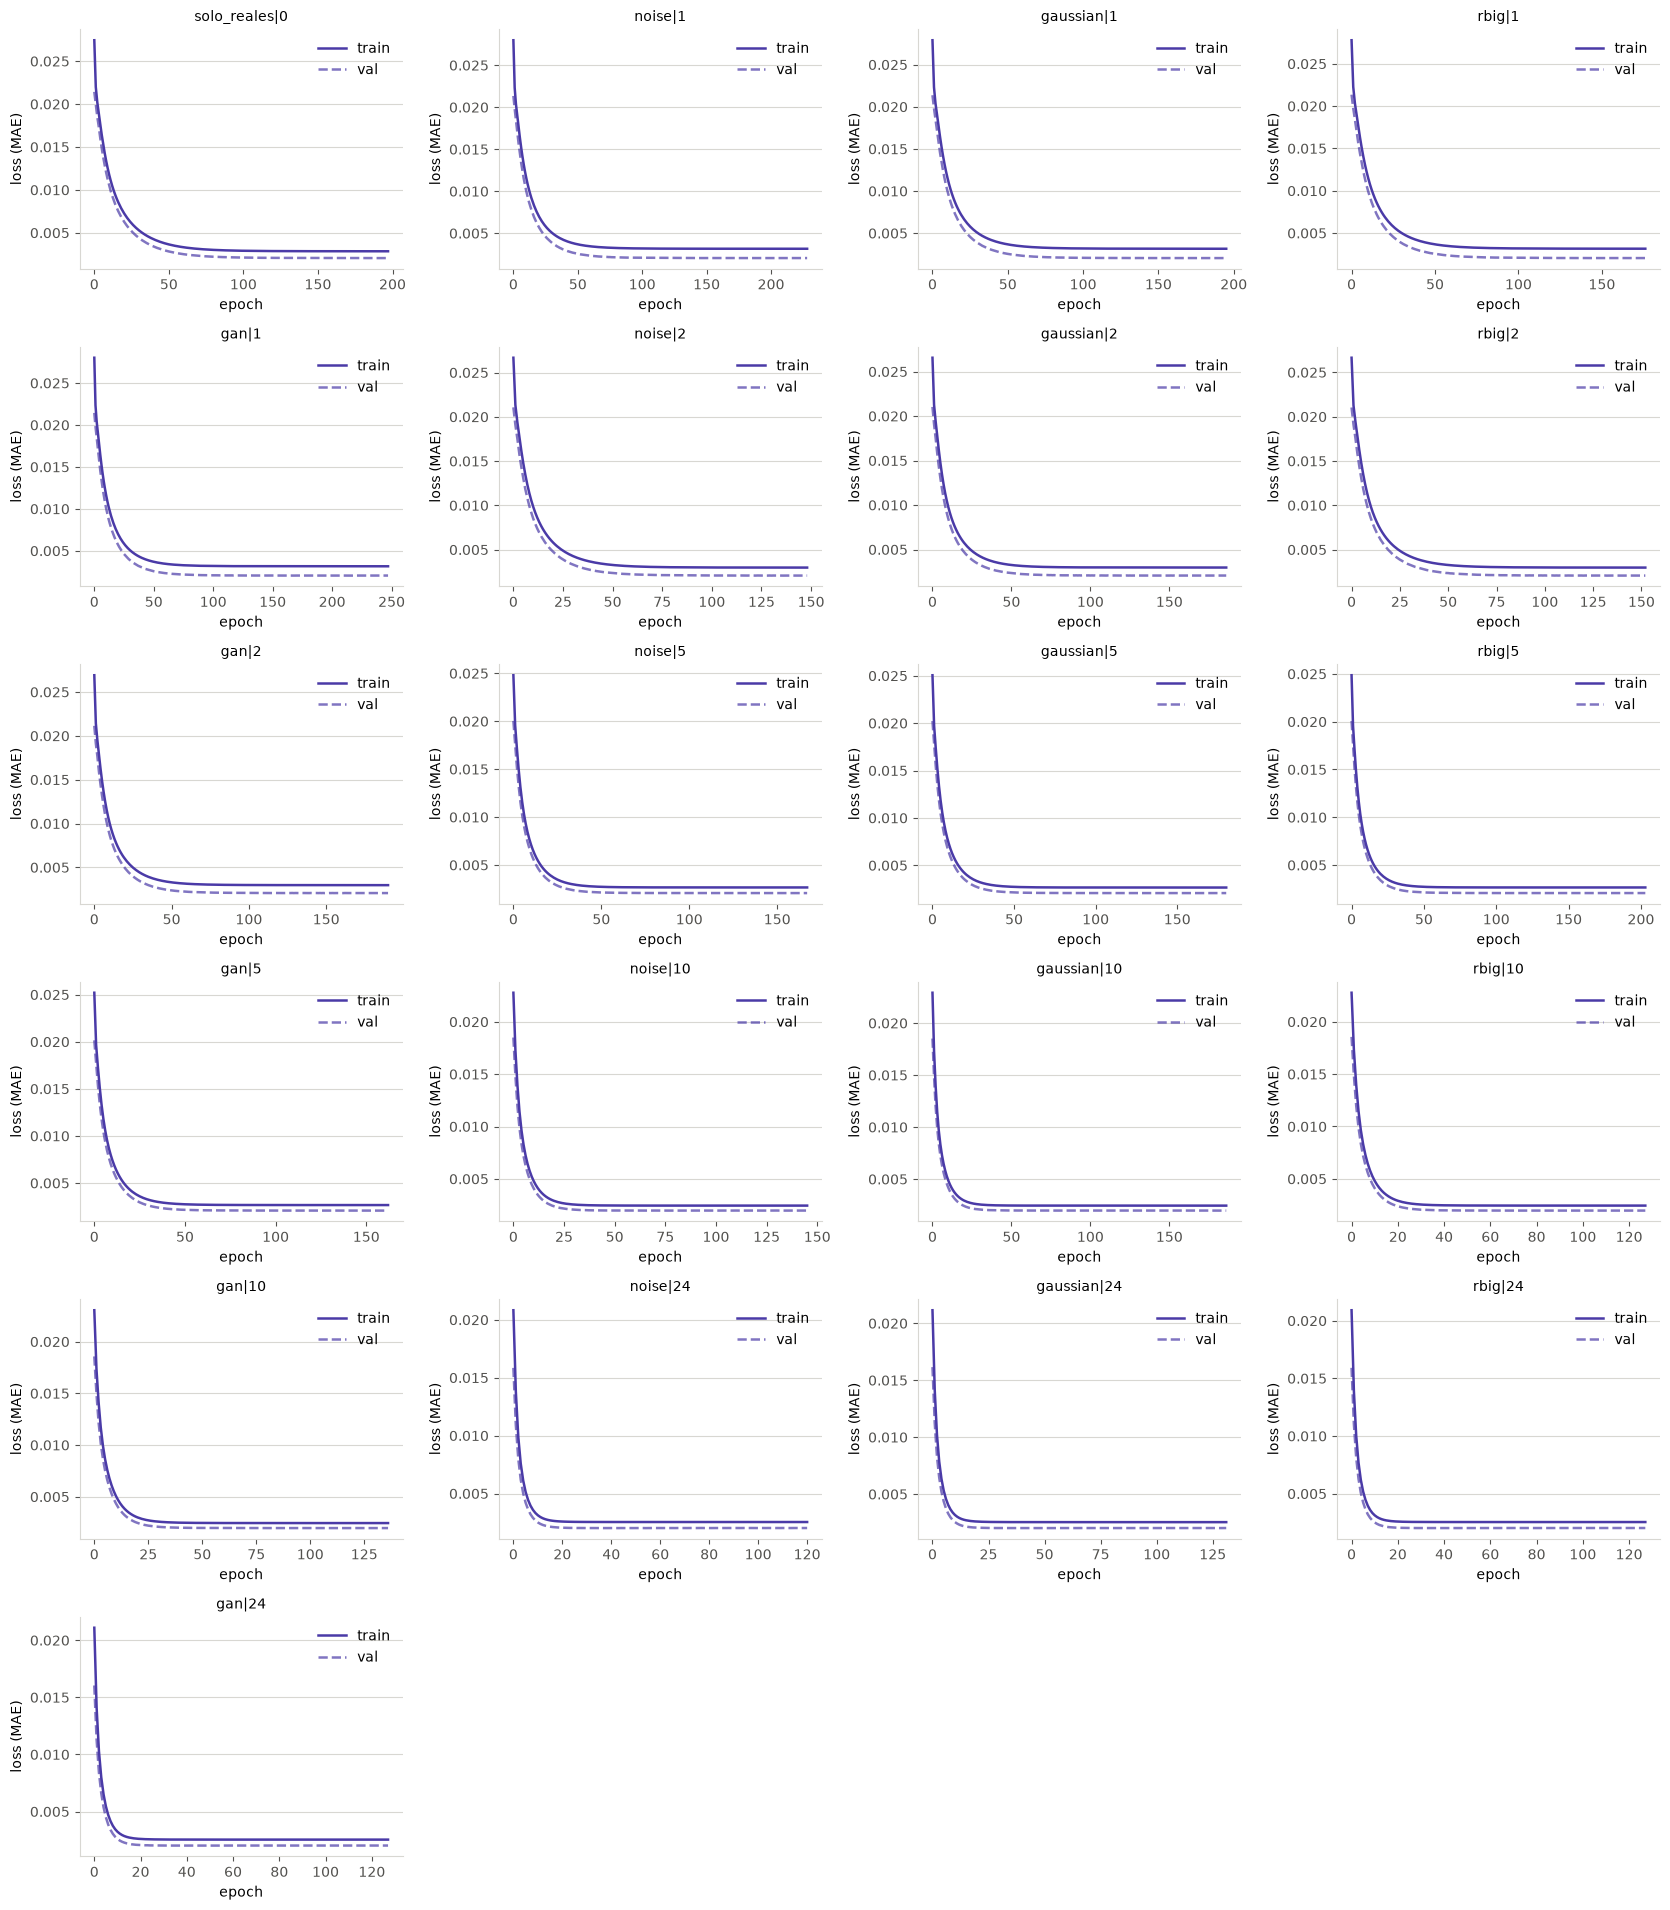

In [10]:
fig = pl.plot_loss_grid(historiales, ncols=4)
pl.savefig(fig, "05_loss_curvas_30dias")
fig

In [11]:
subidas = {k: (np.array(h["val_loss"])[-1] - min(h["val_loss"])) / min(h["val_loss"]) * 100
           for k, h in historiales.items()}
s = pd.Series(subidas)
print(f"subida de val_loss tras el mínimo: mediana {s.median():+.2f}%  máximo {s.max():+.2f}%")
print("(cerca de 0 % = curva plana tras converger, sin sobreajuste posterior)")

subida de val_loss tras el mínimo: mediana +0.17%  máximo +0.43%
(cerca de 0 % = curva plana tras converger, sin sobreajuste posterior)
